In [7]:
!uv pip install shap lime xgboost

Using Python 3.12.13 environment at: /usr
Checked 3 packages in 98ms


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error
import warnings
warnings.filterwarnings('ignore')

In [9]:
# 데이터 로드
df = pd.read_csv('train.csv')

# 실습을 위한 주요 Feature 선택
feature_cols = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
                'FullBath', 'YearBuilt', 'LotArea']
cat_cols = ['Neighborhood', 'BldgType', 'HouseStyle']

# 결측치 처리 (간단히 0으로 대체)
for col in feature_cols:
    df[col] = df[col].fillna(0)

# 범주형 데이터 Label Encoding
le_dict = {}
for col in cat_cols:
    df[col] = df[col].fillna('None')
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    feature_cols.append(col + '_encoded')

X = df[feature_cols]
y = df['SalePrice']

# Train/Test 분할 & XGBoost 훈련
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
model.fit(X_train, y_train)

# 성능 확인
y_pred = model.predict(X_test)

# 로그 계산을 위해 예측값이 음수가 나오지 않도록 0 미만의 값을 0으로 자름 (클리핑)
y_pred = np.clip(y_pred, 0, None)

# RMSLE 계산 (mean_squared_log_error 결과에 루트를 씌움)
rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSLE: {rmsle:.4f}")
print(f"R²: {r2:.4f}")

RMSLE: 0.1595
R²: 0.9006


In [10]:

# 데이터 로드
df = pd.read_csv('train.csv')

# 1) 결측치 비율 5% 이상 컬럼 개수
missing_ratio = df.isnull().sum() / len(df)
missing_over_5 = missing_ratio[missing_ratio >= 0.05]
print(f"\n1) 결측치 비율 5% 이상 컬럼 개수: {len(missing_over_5)}개")
if len(missing_over_5) > 0:
    print(f"   -> 해당 컬럼: {list(missing_over_5.index)}")


1) 결측치 비율 5% 이상 컬럼 개수: 12개
   -> 해당 컬럼: ['LotFrontage', 'Alley', 'MasVnrType', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']


In [11]:
# 2) 중복 행 존재 여부 / 개수
dup_count = df.duplicated().sum()
has_dup = 'Y' if dup_count > 0 else 'N'
print(f"\n2) 중복 행 존재 여부: {has_dup} / 개수: {dup_count}개")


2) 중복 행 존재 여부: N / 개수: 0개


In [12]:
# 3) 타깃 분포 (SalePrice 기준 min/median/max)
target = 'SalePrice'
if target in df.columns:
    t_min = df[target].min()
    t_median = df[target].median()
    t_max = df[target].max()
    print(f"\n3) 타깃 분포 ({target})")
    print(f"   -> Min: {t_min:,.0f} / Median: {t_median:,.0f} / Max: {t_max:,.0f}")
else:
    print(f"\n3) 타깃 컬럼('{target}')이 존재하지 않습니다.")


3) 타깃 분포 (SalePrice)
   -> Min: 34,900 / Median: 163,000 / Max: 755,000


In [13]:
# 4) 수치형 컬럼 개수 / 범주형 컬럼 개수
# (Id 컬럼은 분석에 무의미하므로 제외하거나, 기본 dtypes 기준으로 계산)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns
print(f"\n4) 수치형 컬럼 개수: {len(num_cols)}개 / 범주형 컬럼 개수: {len(cat_cols)}개")


4) 수치형 컬럼 개수: 38개 / 범주형 컬럼 개수: 43개


In [14]:
# 6) 피처 간 leakage 의심 항목 (도메인 지식 기반 + 상관계수 확인)
# 타깃과 상관관계가 1.0이거나 지나치게 높은 변수 확인 (보통 0.9 이상이면 의심)
print("\n6) 피처 간 Leakage 의심 항목")
if target in df.columns:
    # 수치형 변수만 상관계수 계산
    corr_matrix = df[num_cols].corr()
    high_corr = corr_matrix[target][(corr_matrix[target] > 0.9) & (corr_matrix[target] < 1.0)]
    if len(high_corr) > 0:
        print(f"   -> 높은 상관계수(>0.9)로 인한 의심: {list(high_corr.index)}")
    else:
        print("   -> 수치형 변수 중 타깃과 상관계수 0.9 이상인 Leakage 의심 항목 없음.")
    print("   -> 도메인 지식 기반 의심: ['SaleType', 'SaleCondition'] (판매 시점의 조건이므로 예측 시점에 알 수 없는 정보일 수 있음)")


6) 피처 간 Leakage 의심 항목
   -> 수치형 변수 중 타깃과 상관계수 0.9 이상인 Leakage 의심 항목 없음.
   -> 도메인 지식 기반 의심: ['SaleType', 'SaleCondition'] (판매 시점의 조건이므로 예측 시점에 알 수 없는 정보일 수 있음)


In [15]:
# 실습을 위한 주요 Feature 선택
feature_cols = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
                'FullBath', 'YearBuilt', 'LotArea']
cat_cols = ['Neighborhood', 'BldgType', 'HouseStyle']

# 결측치 처리 (간단히 0으로 대체)
for col in feature_cols:
    df[col] = df[col].fillna(0)

# 범주형 데이터 Label Encoding
le_dict = {}
for col in cat_cols:
    df[col] = df[col].fillna('None')
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    feature_cols.append(col + '_encoded')

X = df[feature_cols]
y = df['SalePrice']

# Train/Test 분할 & XGBoost 훈련
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
model.fit(X_train, y_train)

# 성능 확인
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.1f}")
print(f"R²: {r2:.4f}")

RMSE: 27609.1
R²: 0.9006


- R² 0.9006 : 모델이 주택 가격 변동성의 약 90%를 설명

- RMSE가 27,609.1 : 모델이 예측한 집값이 실제 집값과 평균적으로 약 2만 7천 달러 정도의 오차를 가짐

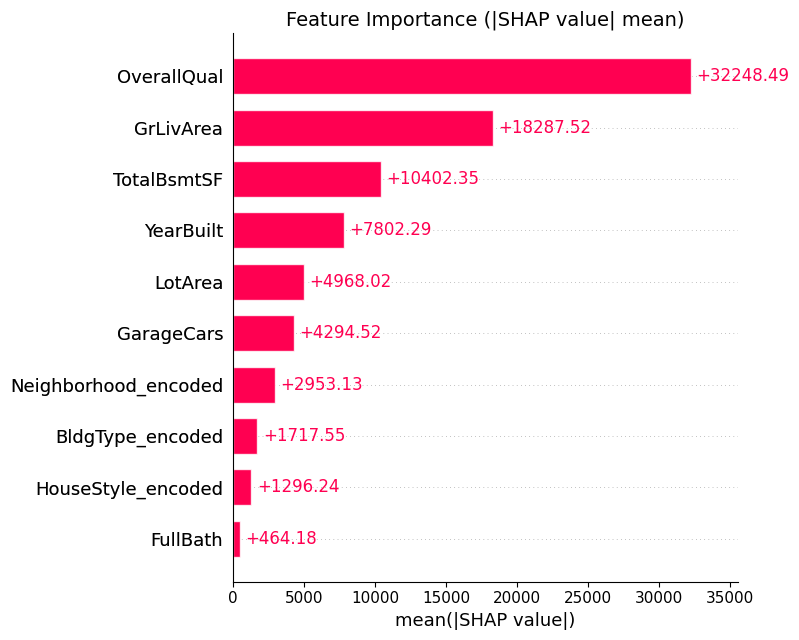

In [16]:
# SHAP TreeExplainer 생성 & SHAP values 계산
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# 1. Summary Plot (막대 그래프) — 글로벌 Feature 기여도를 시각화하고 해석
shap.plots.bar(shap_values, show=False)
plt.title('Feature Importance (|SHAP value| mean)', fontsize=14)
plt.tight_layout()
plt.show()

- 모델이 주택 가격을 예측할 때 **전체적으로 어떤 변수를 가장 중요하게 취급했는지**를 보여주는 '글로벌 해석'지표
(막대가 길수록 집값을 결정할 때 해당 변수가 결정적인 기준)
- Y축(피쳐 순위): 위쪽에 위치할수록 모델 예측에 가장 큰 영향력을 행사한 핵심 변수. 전반적인 품질(OverallQual)이나 지상 층 면적(GrLivArea)이 최상단에 위치
- X축(Mean): 각 변수가 주택 가격 예측값을 평균적으로 얼마나 변동시켰는지 그 '크기(절댓값)'를 나타냄



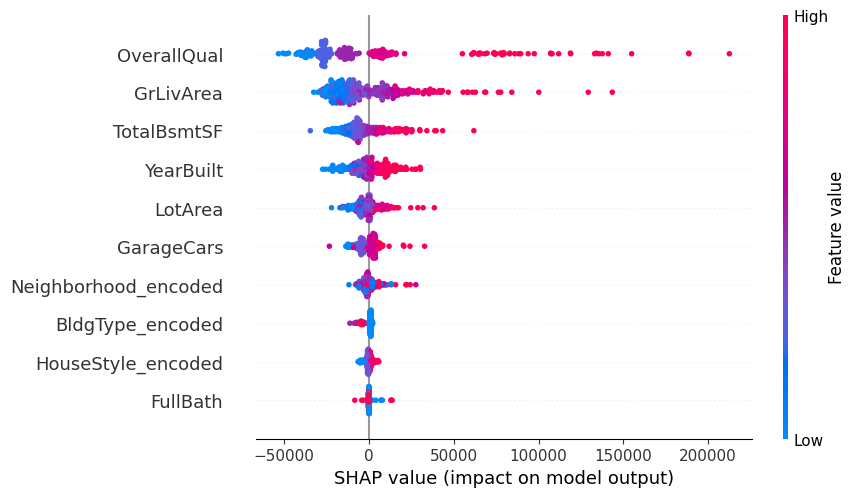

In [17]:
# 2. Beeswarm Plot — Feature 기여도 정량화 시각화
shap.plots.beeswarm(shap_values)

- 색상 (Feature Value): 점의 색상이 빨간색일수록 해당 변수의 실제 값(예: 면적, 품질 등)이 높다는 것을 의미하고 파란색일수록 낮다는 것을 의미

- X축 (SHAP Value): 가운데 0을 기준으로 오른쪽에 위치할수록 주택 가격을 높게(비싸게) 예측하는 데 기여했고, 왼쪽에 위치할수록 가격을 낮게(싸게) 예측하는 데 기여

전반적 품질 (OverallQual): 그래프 최상단에 위치한 가장 중요한 변수입니다.

1.   빨간색 점(품질이 높음)들이 0을 기준으로 오른쪽(+ 영역)으로 길게 뻗어 있음. 집의 전반적인 퀄리티가 우수할수록 집값이 상승하며 반대로 품질이 낮을 경우(파란색 점) 집값을 깎아내리는 주된 요인
2.   지상 층 면적 (GrLivArea): 두 번째로 영향력이 큰 변수. 집이 넓을수록(빨간색) 가격 상승에 양(+)의 영향을 주지만, 품질(OverallQual)만큼 극단적인 상승 폭을 만들지는 못함
3.   건축 연도 (YearBuilt), 지하실 면적 (TotalBsmtSF), 차고 크기 (GarageCars): 정비례 관계를 명확히 보여줌 다만 그 영향력의 폭은 면적이나 품질에 비해 상대적으로 좁게 모여 있음


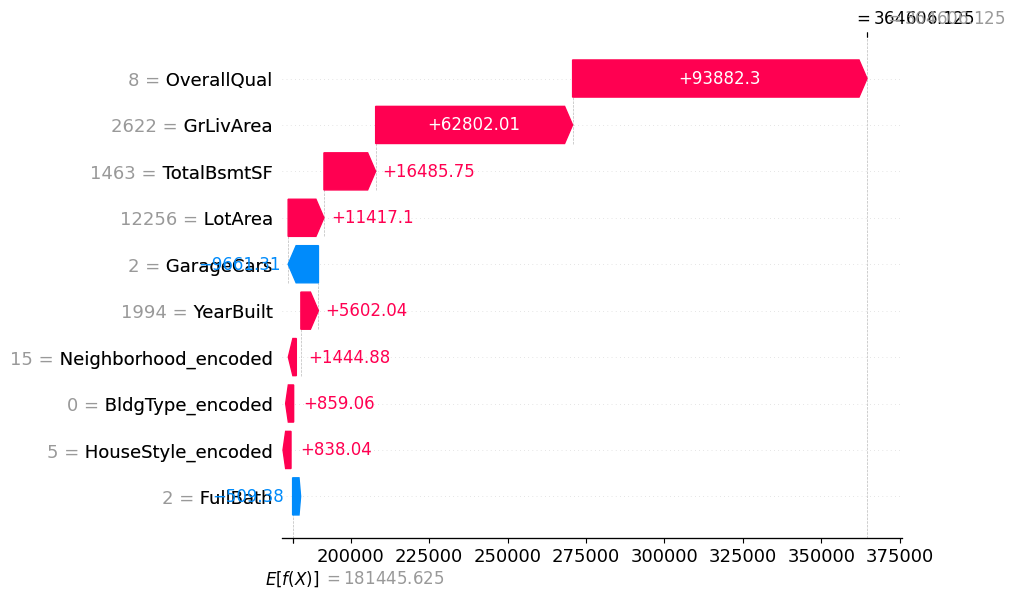

In [18]:
# 테스트 세트의 첫 번째 주택(i=99)에 대한 Waterfall Plot 그리기
shap.plots.waterfall(shap_values[1])

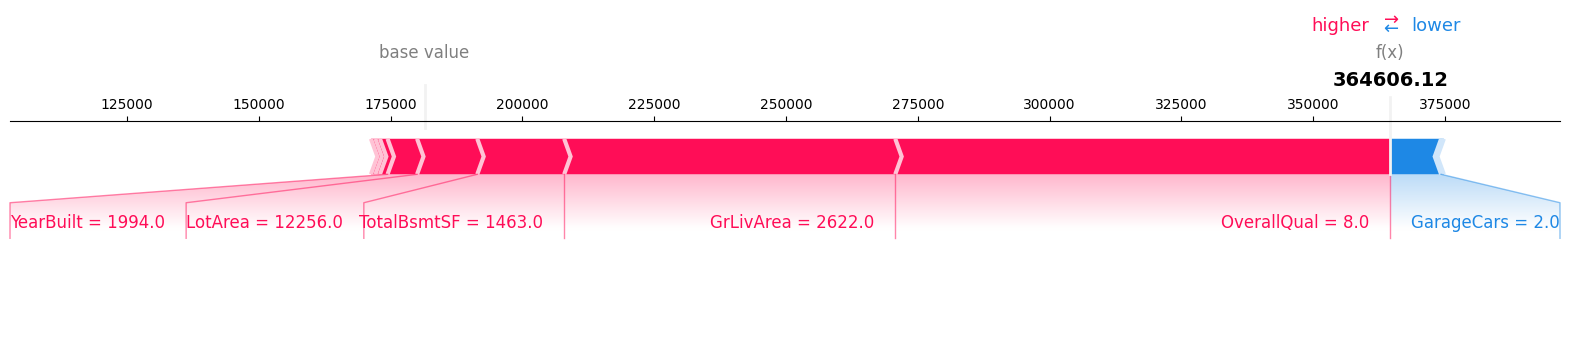

In [19]:
shap.plots.force(shap_values[1], matplotlib=True, show=False)

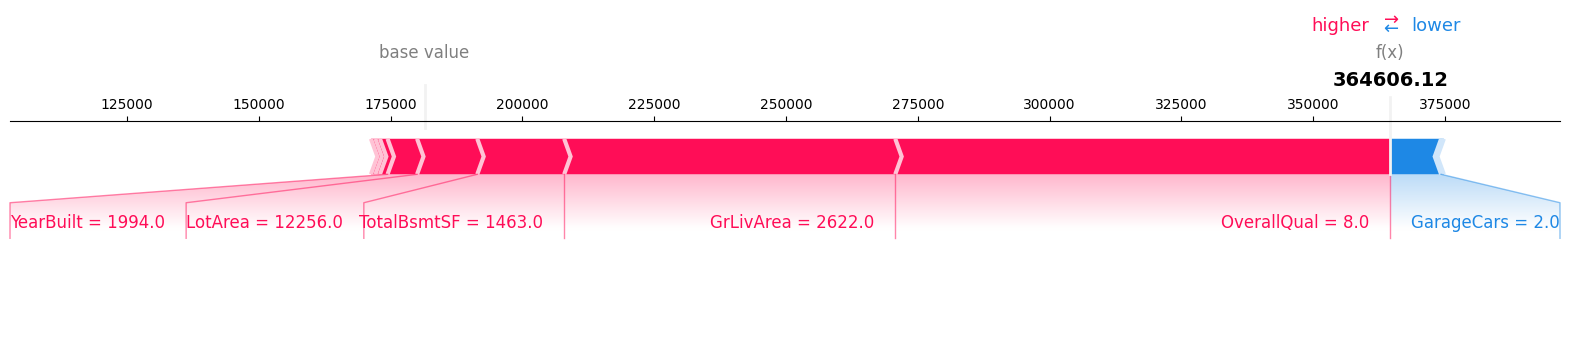

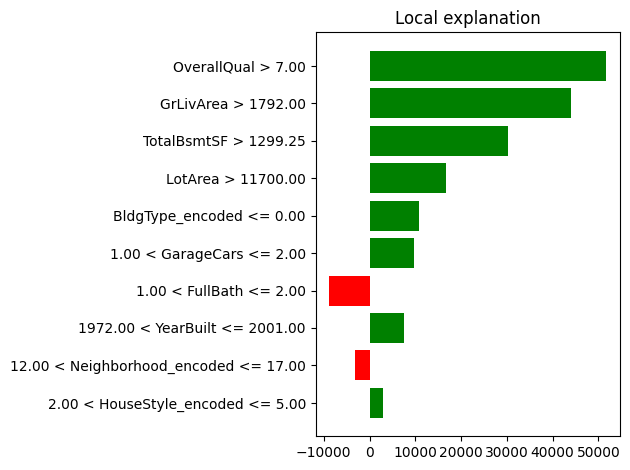

In [20]:
# LIME Tabular Explainer 생성
lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['SalePrice'],
    mode='regression',
    random_state=42
)

# 예측을 설명할 개별 샘플 선택 (X_test의 첫 번째 데이터)
i = 1
exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[i].values,
    predict_fn=model.predict
)

# 결과 시각화 - Feature Importance Bar
exp.show_in_notebook(show_table=True)
exp.as_pyplot_figure()
plt.tight_layout()
plt.show()